
# Compare \(M_4\) with \(M_2^2\) versus system size

This notebook reads the right-boundary JSON results, fixes one value of

\[
P_x=P_{zz}=P,
\]

and compares

\[
M_4(L)
\qquad\text{with}\qquad
M_2(L)^2
\]

on a log-log plot with \(L\) on the horizontal axis.

For the Rényi-2 Binder parameter

\[
B_2
=
1-\frac{M_4}{3M_2^2},
\]

a size-independent ratio

\[
\frac{M_4}{M_2^2}\to \text{constant}
\]

implies

\[
M_4\propto M_2^2.
\]

If both quantities follow power laws in \(L\), they should therefore have the same log-log slope and appear asymptotically parallel.

However, parallel curves alone do **not** prove a critical Binder crossing: the ratio can also approach a constant inside an ordered or disordered phase. The notebook therefore also plots

\[
R(L)=\frac{M_4}{M_2^2}
\]

and reconstructs \(B_2(L)\).


In [1]:

import Pkg

for pkg in ["JSON3", "DataFrames", "Plots"]
    if Base.find_package(pkg) === nothing
        Pkg.add(pkg)
    end
end

using JSON3
using DataFrames
using Statistics
using LinearAlgebra
using Printf
using Plots
using DelimitedFiles

default(
    framestyle = :box,
    grid = false,
    markerstrokewidth = 0.8,
    linewidth = 2,
    size = (780, 520),
)


## 1. User settings

In [ ]:

# Directory containing JSON files, or one JSON file.
DATA_PATH = "right_boundary_results_20260710_1229"

# Fix one probability for the detailed plots.
P_FIELD  = :P_x
P_TARGET = 0.30
P_TOL    = 1e-10

# :exact   -> stop if P_TARGET is unavailable
# :nearest -> use the closest P having enough distinct L values
P_SELECTION_MODE = :nearest

# Parameters fixed throughout this scan.
FIXED_FILTERS = Dict(
    :lambda_x  => 0.7,
    :lambda_zz => 0.0,
)

# The right-boundary scan shown in your figures uses P_x = P_zz.
COUPLE_PX_PZZ = true

EXPECTED_L = [8, 16, 24, 32, 40]
MIN_DISTINCT_L = 3

OUTPUT_DIR = "right_boundary_M2sq_M4_comparison_output"


"right_boundary_M2sq_M4_comparison_output"

## 2. Robust JSON loader

In [3]:

function resolve_data_path(path::AbstractString)
    if ispath(path)
        return path
    elseif isfile(path * ".json")
        return path * ".json"
    else
        error(
            "Could not find '$path' or '$path.json'. " *
            "Set DATA_PATH to the correct directory or JSON file."
        )
    end
end

function json_files_under(path::AbstractString)
    resolved = resolve_data_path(path)

    if isfile(resolved)
        return [resolved]
    end

    files = String[]
    for (root, _, names) in walkdir(resolved)
        for name in names
            if endswith(lowercase(name), ".json")
                push!(files, joinpath(root, name))
            end
        end
    end

    sort!(files)
    isempty(files) && error("No .json files found under '$resolved'.")
    return files
end

function object_to_dict(obj)
    return Dict{String,Any}(string(k) => v for (k, v) in pairs(obj))
end

function normalize_json_object(obj, path::AbstractString)
    if obj isa AbstractVector
        return [object_to_dict(item) for item in obj]
    end

    if obj isa JSON3.Object
        if haskey(obj, :results) && obj[:results] isa AbstractVector
            return [object_to_dict(item) for item in obj[:results]]
        elseif haskey(obj, "results") && obj["results"] isa AbstractVector
            return [object_to_dict(item) for item in obj["results"]]
        else
            return [object_to_dict(obj)]
        end
    end

    error("Unsupported top-level JSON structure in '$path'.")
end

function try_parse_json_lines(text::AbstractString, path::AbstractString)
    rows = Dict{String,Any}[]

    for (line_number, line) in enumerate(eachline(IOBuffer(text)))
        stripped = strip(line)
        isempty(stripped) && continue

        try
            obj = JSON3.read(stripped)
            append!(rows, normalize_json_object(obj, path))
        catch err
            @warn(
                "JSON-lines fallback failed; file will be skipped.",
                file = path,
                line = line_number,
                error = sprint(showerror, err),
            )
            return Dict{String,Any}[]
        end
    end

    return rows
end

function records_from_json_file(path::AbstractString)
    text = read(path, String)

    if isempty(strip(text))
        @warn "Skipping empty JSON file." file=path
        return Dict{String,Any}[]
    end

    try
        obj = JSON3.read(text)
        return normalize_json_object(obj, path)
    catch err
        rows = try_parse_json_lines(text, path)

        if !isempty(rows)
            @info "Parsed file as JSON Lines." file=path records=length(rows)
            return rows
        end

        @warn(
            "Skipping malformed or incomplete JSON file.",
            file = path,
            bytes = filesize(path),
            error = sprint(showerror, err),
        )
        return Dict{String,Any}[]
    end
end

function dicts_to_dataframe(rows::Vector{Dict{String,Any}})
    isempty(rows) && return DataFrame()

    all_keys = sort(unique(vcat([collect(keys(row)) for row in rows]...)))
    columns = Dict{Symbol,Vector{Any}}()

    for key in all_keys
        columns[Symbol(key)] = [get(row, key, missing) for row in rows]
    end

    return DataFrame(columns)
end

json_files = json_files_under(DATA_PATH)
println("Found $(length(json_files)) JSON file(s).")

empty_files = filter(file -> filesize(file) == 0, json_files)
if !isempty(empty_files)
    println("\nZero-byte JSON files that will be skipped:")
    foreach(file -> println("  ", file), empty_files)
end

records = Dict{String,Any}[]
files_with_records = 0

for file in json_files
    file_records = records_from_json_file(file)
    if !isempty(file_records)
        append!(records, file_records)
        files_with_records += 1
    end
end

isempty(records) && error(
    "No valid JSON records were loaded. Check DATA_PATH and the warnings above."
)

df_raw = dicts_to_dataframe(records)

println("\nLoaded $(nrow(df_raw)) record(s) from $files_with_records valid file(s).")
println("Columns:")
println(names(df_raw))


Found 1788 JSON file(s).

Zero-byte JSON files that will be skipped:
  right_boundary_results_20260710_1229/failed/right_boundary_L10_lx0.30_lzz0.00_Px0.15_s12_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L10_lx0.30_lzz0.00_Px0.15_s19_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.35_s3_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.40_s27_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.45_s12_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.70_lzz0.00_Px0.45_s1_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L14_lx0.30_lzz0.00_Px0.00_s15_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L8_lx0.30_lzz0.00_Px0.00_s27_FAILED.json
  right_boundary_results_20260710_1229/failed/right_boundary_L8_lx0.30_lzz0.00_Px0.00_s28_FAILED.json
  right_

┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L10_lx0.30_lzz0.00_Px0.15_s12_FAILED.json
└ @ Main /Users/qiawang/Desktop/binder-parameter-OSpool/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:86
┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L10_lx0.30_lzz0.00_Px0.15_s19_FAILED.json
└ @ Main /Users/qiawang/Desktop/binder-parameter-OSpool/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:86



Loaded 1754 record(s) from 1754 valid file(s).


┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.35_s3_FAILED.json
└ @ Main /Users/qiawang/Desktop/binder-parameter-OSpool/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:86
┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.40_s27_FAILED.json
└ @ Main /Users/qiawang/Desktop/binder-parameter-OSpool/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:86
┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.30_lzz0.00_Px0.45_s12_FAILED.json
└ @ Main /Users/qiawang/Desktop/binder-parameter-OSpool/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:86
┌ Warning: Skipping empty JSON file.
│   file = right_boundary_results_20260710_1229/failed/right_boundary_L12_lx0.70_lzz0.00_Px0.45_s1_FAILED.json
└ @ Main /Users/qiawang/Desktop/bi

Columns:
["B", "B2_ratio_of_mean_moments", "B_bootstrap_se", "B_ci_high", "B_ci_low", "B_mean_of_trials", "B_std_of_trials", "L", "M2_bar", "M4_bar", "P_x", "P_zz", "T_max", "cutoff", "lambda_x", "lambda_zz", "max_interphysical_linkdim", "max_trace_error", "maxdim", "n_invalid", "n_valid", "ntrials", "purity_bar", "time_seconds"]


## 3. Convert numeric columns and define derived quantities

In [4]:

function convert_numeric_column!(df::DataFrame, col::Symbol; integer::Bool=false)
    col ∉ propertynames(df) && return df

    if integer
        df[!, col] = [
            ismissing(x) ? missing : Int(round(Float64(x)))
            for x in df[!, col]
        ]
    else
        df[!, col] = [
            ismissing(x) ? missing : Float64(x)
            for x in df[!, col]
        ]
    end

    return df
end

df = copy(df_raw)

convert_numeric_column!(df, :L; integer=true)

for col in [
    :P_x, :P_zz, :lambda_x, :lambda_zz,
    :M2_bar, :M4_bar, :B, :B2_ratio_of_mean_moments,
    :purity_bar, :n_valid, :ntrials
]
    convert_numeric_column!(df, col)
end

required_columns = [:L, :M2_bar, :M4_bar, P_FIELD]
missing_columns = [c for c in required_columns if c ∉ propertynames(df)]
isempty(missing_columns) || error("Missing required columns: $missing_columns")

# Derived quantities used throughout the notebook.
df.M2_squared = df.M2_bar .^ 2
df.ratio_M4_over_M2sq = df.M4_bar ./ df.M2_squared
df.B_reconstructed = 1 .- df.ratio_M4_over_M2sq ./ 3

println("Available L values: ", sort(unique(collect(skipmissing(df.L)))))
println(
    "Available $(P_FIELD) values: ",
    sort(unique(collect(skipmissing(df[!, P_FIELD])))),
)


Available L values: [8, 16, 24, 32]
Available P_x values: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


## 4. Apply the right-boundary filters and select one \(P\)

In [5]:

function approximately_equal(x, target; atol=1e-10)
    return !ismissing(x) && isapprox(Float64(x), Float64(target); atol=atol, rtol=0)
end

df_fixed = copy(df)

println("Rows before fixed-parameter filters: ", nrow(df_fixed))

for (col, target) in FIXED_FILTERS
    if col in propertynames(df_fixed)
        before = nrow(df_fixed)
        df_fixed = filter(
            row -> approximately_equal(row[col], target; atol=P_TOL),
            df_fixed,
        )
        println("Filter $col = $target: $before -> $(nrow(df_fixed)) rows")
    else
        @warn "Filter column absent; skipping filter." column=col
    end
end

if COUPLE_PX_PZZ && (:P_x in propertynames(df_fixed)) && (:P_zz in propertynames(df_fixed))
    before = nrow(df_fixed)
    df_fixed = filter(
        row -> !ismissing(row.P_x) &&
               !ismissing(row.P_zz) &&
               isapprox(Float64(row.P_x), Float64(row.P_zz); atol=P_TOL, rtol=0),
        df_fixed,
    )
    println("Filter P_x = P_zz: $before -> $(nrow(df_fixed)) rows")
end

isempty(df_fixed) && error("No rows remain after the right-boundary filters.")

P_counts = combine(
    groupby(dropmissing(df_fixed, P_FIELD), P_FIELD),
    nrow => :n_records,
    :L => (x -> length(unique(x))) => :n_distinct_L,
    :L => (x -> join(sort(unique(x)), ", ")) => :available_L,
)
sort!(P_counts, P_FIELD)

println("\nAvailable $(P_FIELD) values after filtering:")
display(P_counts)

eligible = filter(row -> row.n_distinct_L >= MIN_DISTINCT_L, P_counts)
isempty(eligible) && error(
    "No P value has at least $MIN_DISTINCT_L distinct system sizes."
)

available_P_eligible = Float64.(eligible[!, P_FIELD])
requested_P = Float64(P_TARGET)

exact_index = findfirst(
    p -> isapprox(p, requested_P; atol=P_TOL, rtol=0),
    available_P_eligible,
)

if exact_index !== nothing
    P_USED = available_P_eligible[exact_index]
elseif P_SELECTION_MODE == :nearest
    nearest_index = argmin(abs.(available_P_eligible .- requested_P))
    P_USED = available_P_eligible[nearest_index]
    @warn(
        "Requested P unavailable with enough L values; using nearest eligible P.",
        requested = requested_P,
        used = P_USED,
    )
elseif P_SELECTION_MODE == :exact
    nearest = available_P_eligible[argmin(abs.(available_P_eligible .- requested_P))]
    error(
        "P_TARGET=$requested_P unavailable with enough sizes. " *
        "Nearest eligible value is $nearest."
    )
else
    error("P_SELECTION_MODE must be :exact or :nearest.")
end

df_P = filter(
    row -> approximately_equal(row[P_FIELD], P_USED; atol=P_TOL),
    df_fixed,
)

safe_std(v) = length(v) > 1 ? std(v) : 0.0

summary_P = combine(
    groupby(df_P, :L),
    :M2_bar => mean => :M2_mean,
    :M2_bar => safe_std => :M2_std_across_records,
    :M4_bar => mean => :M4_mean,
    :M4_bar => safe_std => :M4_std_across_records,
    nrow => :n_records,
)

sort!(summary_P, :L)

# Derive M2^2 and Binder from the mean moments.
summary_P.M2sq_from_means = summary_P.M2_mean .^ 2
summary_P.ratio = summary_P.M4_mean ./ summary_P.M2sq_from_means
summary_P.B_reconstructed = 1 .- summary_P.ratio ./ 3

println("\nRequested $(P_FIELD) = $P_TARGET")
println("Actually using $(P_FIELD) = $P_USED")
println("Distinct L at selected P: ", sort(unique(df_P.L)))
display(summary_P)

length(unique(summary_P.L)) >= MIN_DISTINCT_L || error(
    "Selected P has fewer than $MIN_DISTINCT_L distinct L values."
)


Rows before fixed-parameter filters: 1754
Filter lambda_zz = 0.0: 1754 -> 1754 rows
Filter lambda_x = 0.7: 1754 -> 1754 rows
Filter P_x = P_zz: 1754 -> 1750 rows

Available P_x values after filtering:

Requested P_x = 0.3
Actually using P_x = 0.3
Distinct L at selected P: [8, 16, 24, 32]


Row,P_x,n_records,n_distinct_L,available_L
,Float64,Int64,Int64,String
1,0.0,160,4,"8, 16, 24, 32"
2,0.05,160,4,"8, 16, 24, 32"
3,0.1,160,4,"8, 16, 24, 32"
4,0.15,159,4,"8, 16, 24, 32"
5,0.2,159,4,"8, 16, 24, 32"
6,0.25,159,4,"8, 16, 24, 32"
7,0.3,160,4,"8, 16, 24, 32"
8,0.35,157,4,"8, 16, 24, 32"
9,0.4,159,4,"8, 16, 24, 32"


Row,L,M2_mean,M2_std_across_records,M4_mean,M4_std_across_records,n_records,M2sq_from_means,ratio,B_reconstructed
,Int64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64
1,8,0.556426,0.00654302,0.473214,0.00700565,40,0.309609,1.52842,0.490526
2,16,0.39651,0.0105691,0.282977,0.0100701,40,0.15722,1.79988,0.400042
3,24,0.318069,0.00833029,0.196278,0.00703025,40,0.101168,1.94012,0.353295
4,32,0.265959,0.00780478,0.144152,0.00604793,40,0.0707342,2.03794,0.320687


true


## 5. Fit the log-log slopes

If

\[
M_4\sim L^{s_4},
\qquad
M_2^2\sim L^{s_{22}},
\]

then

\[
\frac{M_4}{M_2^2}\sim L^{s_4-s_{22}}.
\]

Therefore:

- \(s_4-s_{22}\approx0\): the two curves are parallel and their ratio is approximately size-independent;
- \(s_4-s_{22}\neq0\): the ratio drifts with \(L\), so the Binder parameter also drifts.


In [6]:

function affine_fit(x::AbstractVector, y::AbstractVector)
    x = Float64.(x)
    y = Float64.(y)

    X = hcat(ones(length(x)), x)
    beta = X \ y
    yhat = X * beta
    residuals = y .- yhat

    rss = sum(abs2, residuals)
    tss = sum(abs2, y .- mean(y))
    r2 = tss > 0 ? 1 - rss / tss : NaN
    rmse = sqrt(rss / length(y))

    return (
        intercept = beta[1],
        slope = beta[2],
        yhat = yhat,
        residuals = residuals,
        rss = rss,
        rmse = rmse,
        r2 = r2,
    )
end

Lvals = Float64.(summary_P.L)
M4vals = Float64.(summary_P.M4_mean)
M2sqvals = Float64.(summary_P.M2sq_from_means)

all(M4vals .> 0) || error("All M4 values must be positive for a log-log fit.")
all(M2sqvals .> 0) || error("All M2^2 values must be positive for a log-log fit.")

fit_M4 = affine_fit(log.(Lvals), log.(M4vals))
fit_M2sq = affine_fit(log.(Lvals), log.(M2sqvals))
fit_ratio = affine_fit(log.(Lvals), log.(M4vals ./ M2sqvals))

slope_difference = fit_M4.slope - fit_M2sq.slope

fit_table = DataFrame(
    quantity = ["M4", "M2^2", "M4/M2^2"],
    loglog_slope = [fit_M4.slope, fit_M2sq.slope, fit_ratio.slope],
    R2 = [fit_M4.r2, fit_M2sq.r2, fit_ratio.r2],
    RSS = [fit_M4.rss, fit_M2sq.rss, fit_ratio.rss],
)

display(fit_table)

@printf("slope(M4)        = %.8f\n", fit_M4.slope)
@printf("slope(M2^2)      = %.8f\n", fit_M2sq.slope)
@printf("slope difference = %.8f\n", slope_difference)
@printf("slope of ratio   = %.8f\n", fit_ratio.slope)

if abs(slope_difference) < 0.05
    println("The two fitted slopes are close over the available sizes.")
else
    println("The two fitted slopes differ noticeably over the available sizes.")
end


Row,quantity,loglog_slope,R2,RSS
,String,Float64,Float64,Float64
1,M4,-0.847558,0.993481,0.00511032
2,M2^2,-1.05621,0.997449,0.00309364
3,M4/M2^2,0.208647,0.994368,0.000267354


slope(M4)        = -0.84755760
slope(M2^2)      = -1.05620501
slope difference = 0.20864741
slope of ratio   = 0.20864741
The two fitted slopes differ noticeably over the available sizes.


## 6. Main log-log comparison: \(M_4\) and \(M_2^2\)

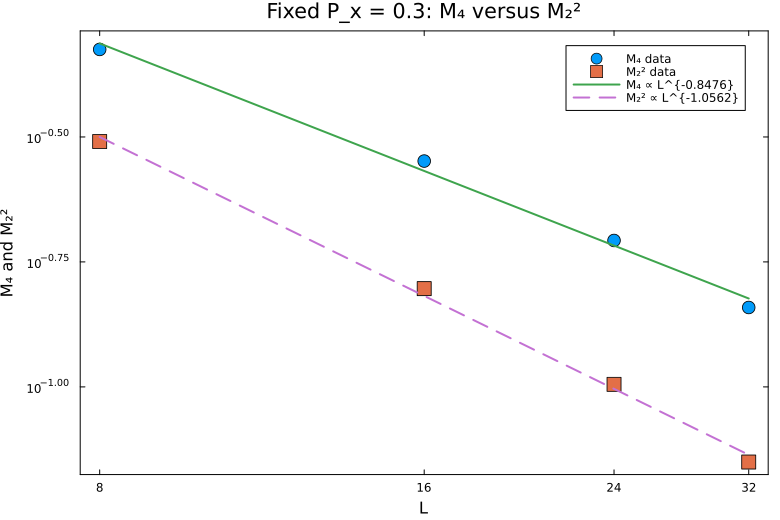

In [7]:

Lgrid = exp.(range(log(minimum(Lvals)), log(maximum(Lvals)), length=300))

A4 = exp(fit_M4.intercept)
A22 = exp(fit_M2sq.intercept)

M4_fit_curve = A4 .* Lgrid .^ fit_M4.slope
M2sq_fit_curve = A22 .* Lgrid .^ fit_M2sq.slope

p_loglog = scatter(
    Lvals,
    M4vals;
    xscale = :log10,
    yscale = :log10,
    xlabel = "L",
    ylabel = "M₄ and M₂²",
    title = "Fixed $(P_FIELD) = $P_USED: M₄ versus M₂²",
    label = "M₄ data",
    markershape = :circle,
    markersize = 7,
    xticks = (Lvals, string.(Int.(Lvals))),
)

scatter!(
    p_loglog,
    Lvals,
    M2sqvals;
    label = "M₂² data",
    markershape = :square,
    markersize = 7,
)

plot!(
    p_loglog,
    Lgrid,
    M4_fit_curve;
    label = @sprintf("M₄ ∝ L^{%.4f}", fit_M4.slope),
)

plot!(
    p_loglog,
    Lgrid,
    M2sq_fit_curve;
    linestyle = :dash,
    label = @sprintf("M₂² ∝ L^{%.4f}", fit_M2sq.slope),
)

p_loglog



## 7. Plot the ratio and reconstructed Binder parameter

The more direct test of parallelism is

\[
R(L)=\frac{M_4}{M_2^2}.
\]

If \(R(L)\) approaches a constant, then the two log-log curves become parallel.

Because

\[
B_2=1-\frac{R}{3},
\]

a constant ratio is exactly equivalent to a size-independent Binder value at that fixed \(P\).


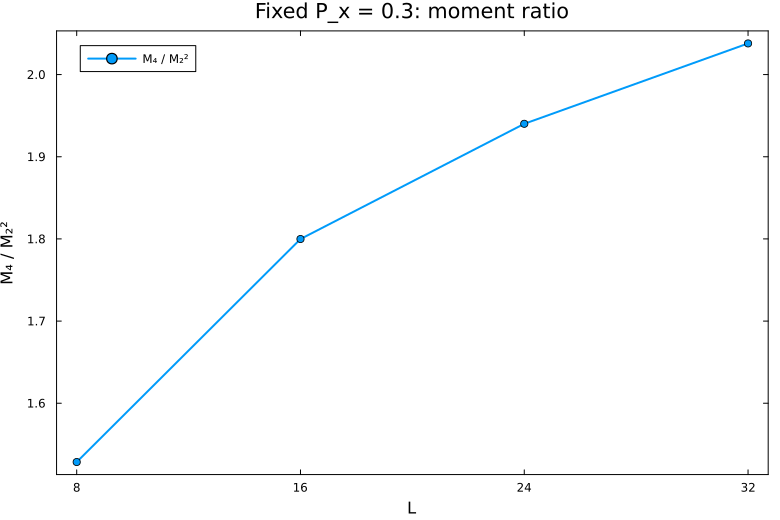

In [8]:

p_ratio = plot(
    Lvals,
    summary_P.ratio;
    marker = :circle,
    xlabel = "L",
    ylabel = "M₄ / M₂²",
    title = "Fixed $(P_FIELD) = $P_USED: moment ratio",
    label = "M₄ / M₂²",
    xticks = (Lvals, string.(Int.(Lvals))),
)

p_ratio


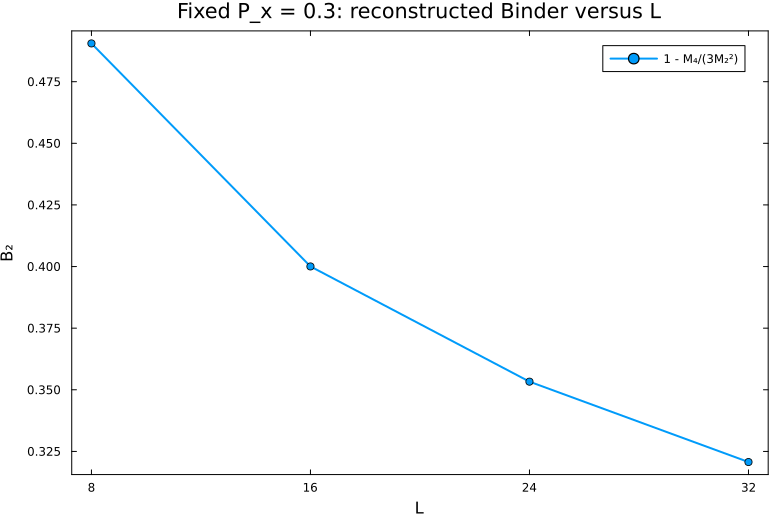

In [9]:

p_binder_L = plot(
    Lvals,
    summary_P.B_reconstructed;
    marker = :circle,
    xlabel = "L",
    ylabel = "B₂",
    title = "Fixed $(P_FIELD) = $P_USED: reconstructed Binder versus L",
    label = "1 - M₄/(3M₂²)",
    xticks = (Lvals, string.(Int.(Lvals))),
)

p_binder_L



## 8. Scan all \(P\): where are the two slopes closest?

This table is a diagnostic. A small value of

\[
\left|s_4-s_{22}\right|
\]

means \(M_4\) and \(M_2^2\) are nearly parallel over the available sizes.

This alone does not identify the critical point. Combine it with the Binder curves versus \(P\), ratio drift, and larger system sizes.


In [10]:

function summarize_one_P(sub::DataFrame)
    grouped = combine(
        groupby(sub, :L),
        :M2_bar => mean => :M2_mean,
        :M4_bar => mean => :M4_mean,
    )
    sort!(grouped, :L)

    if nrow(grouped) < MIN_DISTINCT_L
        return nothing
    end

    L = Float64.(grouped.L)
    M4 = Float64.(grouped.M4_mean)
    M2sq = Float64.(grouped.M2_mean .^ 2)

    if any(M4 .<= 0) || any(M2sq .<= 0)
        return nothing
    end

    fit4 = affine_fit(log.(L), log.(M4))
    fit22 = affine_fit(log.(L), log.(M2sq))
    ratio = M4 ./ M2sq
    fitR = affine_fit(log.(L), log.(ratio))
    Bvals = 1 .- ratio ./ 3

    return (
        n_sizes = length(L),
        slope_M4 = fit4.slope,
        slope_M2sq = fit22.slope,
        slope_difference = fit4.slope - fit22.slope,
        abs_slope_difference = abs(fit4.slope - fit22.slope),
        ratio_loglog_slope = fitR.slope,
        Binder_min = minimum(Bvals),
        Binder_max = maximum(Bvals),
        Binder_range = maximum(Bvals) - minimum(Bvals),
    )
end

rows = NamedTuple[]

for p in sort(unique(collect(skipmissing(df_fixed[!, P_FIELD]))))
    sub = filter(
        row -> approximately_equal(row[P_FIELD], p; atol=P_TOL),
        df_fixed,
    )

    result = summarize_one_P(sub)
    result === nothing && continue

    push!(rows, merge((P = Float64(p),), result))
end

all_P_summary = DataFrame(rows)
sort!(all_P_summary, :P)

display(all_P_summary)

println("\nP values with the smallest absolute slope difference:")
display(first(sort(all_P_summary, :abs_slope_difference), min(10, nrow(all_P_summary))))


Row,P,n_sizes,slope_M4,slope_M2sq,slope_difference,abs_slope_difference,ratio_loglog_slope,Binder_min,Binder_max,Binder_range
,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,4,-1.95165,-2.0,0.0483488,0.0483488,0.0483488,0.0208333,0.0833333,0.0625
2,0.05,4,-1.89191,-1.96357,0.0716629,0.0716629,0.0716629,0.0316484,0.12183,0.0901813
3,0.1,4,-1.80702,-1.91002,0.103002,0.103002,0.103002,0.0471961,0.172129,0.124933
4,0.15,4,-1.66856,-1.80998,0.141421,0.141421,0.141421,0.0744264,0.237366,0.162939
5,0.2,4,-1.45535,-1.63446,0.179113,0.179113,0.179113,0.123016,0.31385,0.190834
6,0.25,4,-1.18734,-1.39857,0.211227,0.211227,0.211227,0.206686,0.405219,0.198533
7,0.3,4,-0.847558,-1.05621,0.208647,0.208647,0.208647,0.320687,0.490526,0.169839
8,0.35,4,-0.488054,-0.648091,0.160037,0.160037,0.160037,0.460449,0.565795,0.105347
9,0.4,4,-0.198151,-0.278066,0.079915,0.079915,0.079915,0.578004,0.62147,0.043466



P values with the smallest absolute slope difference:


Row,P,n_sizes,slope_M4,slope_M2sq,slope_difference,abs_slope_difference,ratio_loglog_slope,Binder_min,Binder_max,Binder_range
,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.5,4,-4.44946e-16,-5.22942e-16,7.79956e-17,7.79956e-17,1.38594e-16,0.666667,0.666667,2.22045e-16
2,0.45,4,-0.0424988,-0.0619087,0.0194099,0.0194099,0.0194099,0.646456,0.655456,0.00900075
3,0.0,4,-1.95165,-2.0,0.0483488,0.0483488,0.0483488,0.0208333,0.0833333,0.0625
4,0.05,4,-1.89191,-1.96357,0.0716629,0.0716629,0.0716629,0.0316484,0.12183,0.0901813
5,0.4,4,-0.198151,-0.278066,0.079915,0.079915,0.079915,0.578004,0.62147,0.043466
6,0.1,4,-1.80702,-1.91002,0.103002,0.103002,0.103002,0.0471961,0.172129,0.124933
7,0.15,4,-1.66856,-1.80998,0.141421,0.141421,0.141421,0.0744264,0.237366,0.162939
8,0.35,4,-0.488054,-0.648091,0.160037,0.160037,0.160037,0.460449,0.565795,0.105347
9,0.2,4,-1.45535,-1.63446,0.179113,0.179113,0.179113,0.123016,0.31385,0.190834


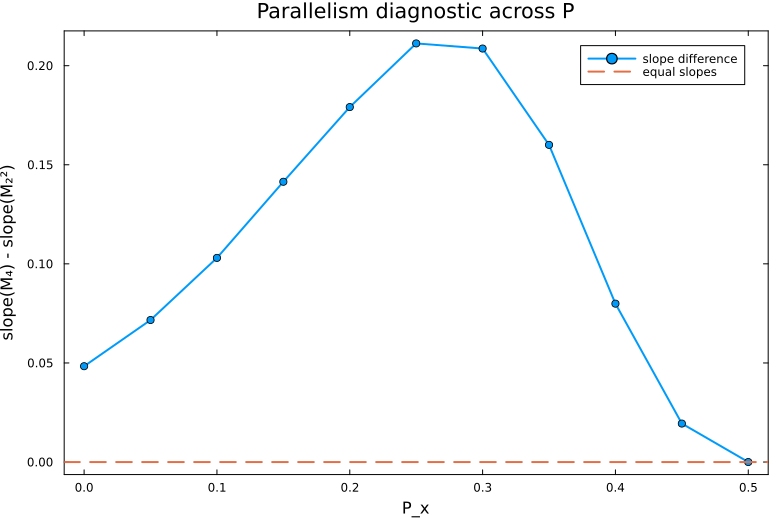

In [11]:

p_slope_difference = plot(
    all_P_summary.P,
    all_P_summary.slope_difference;
    marker = :circle,
    xlabel = string(P_FIELD),
    ylabel = "slope(M₄) - slope(M₂²)",
    title = "Parallelism diagnostic across P",
    label = "slope difference",
)

hline!(p_slope_difference, [0.0]; linestyle = :dash, label = "equal slopes")

p_slope_difference


## 9. Save outputs

In [12]:

mkpath(OUTPUT_DIR)

savefig(
    p_loglog,
    joinpath(OUTPUT_DIR, "M4_vs_M2sq_loglog_$(P_FIELD)_$(P_USED).png"),
)

savefig(
    p_ratio,
    joinpath(OUTPUT_DIR, "ratio_M4_over_M2sq_$(P_FIELD)_$(P_USED).png"),
)

savefig(
    p_binder_L,
    joinpath(OUTPUT_DIR, "Binder_vs_L_$(P_FIELD)_$(P_USED).png"),
)

savefig(
    p_slope_difference,
    joinpath(OUTPUT_DIR, "slope_difference_vs_P.png"),
)

function write_dataframe_csv(path::AbstractString, table::DataFrame)
    open(path, "w") do io
        println(io, join(string.(names(table)), ","))
        for row in eachrow(table)
            println(io, join(string.(collect(row)), ","))
        end
    end
end

write_dataframe_csv(
    joinpath(OUTPUT_DIR, "fixed_P_summary.csv"),
    summary_P,
)

write_dataframe_csv(
    joinpath(OUTPUT_DIR, "fixed_P_loglog_fits.csv"),
    fit_table,
)

write_dataframe_csv(
    joinpath(OUTPUT_DIR, "all_P_parallelism_summary.csv"),
    all_P_summary,
)

println("Saved outputs to: ", abspath(OUTPUT_DIR))


Saved outputs to: /Users/qiawang/Desktop/binder-parameter-OSpool/right_boundary_M2sq_M4_comparison_output



## Interpretation

At a Binder crossing \(P=P_c\), finite-size scaling predicts approximately

\[
B_2(P_c,L)\approx B_2^\star,
\]

so

\[
\frac{M_4}{M_2^2}
\approx
3(1-B_2^\star)
\]

is approximately independent of \(L\). If \(M_4\) and \(M_2^2\) are power laws, their log-log slopes should then agree.

The strongest evidence is therefore the combination of:

1. \(M_4\) and \(M_2^2\) having similar log-log slopes;
2. \(M_4/M_2^2\) becoming flatter with increasing \(L\);
3. \(B_2(P,L)\) from different \(L\) crossing or merging near the same \(P\);
4. the result remaining stable after dropping the smallest size.
